In [86]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load the dataset
df = pd.read_csv("CustomerDataset.csv")
df.drop("customerID", axis=1, inplace=True)

# Fix TotalCharges (convert to numeric)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df.dropna(inplace=True)

In [87]:
# Encode categorical variables
label_encoders = {}
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le


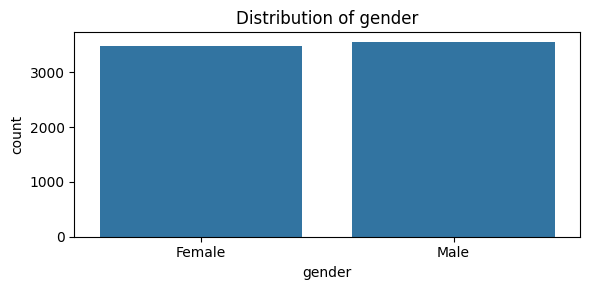

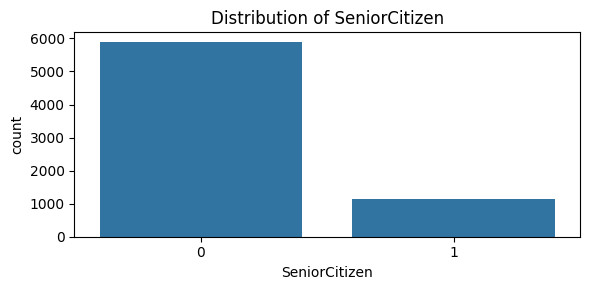

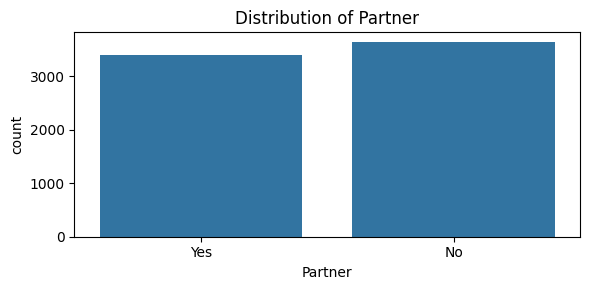

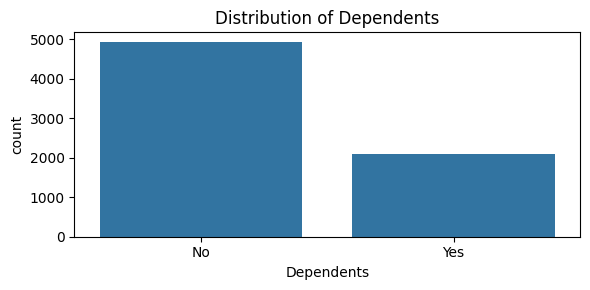

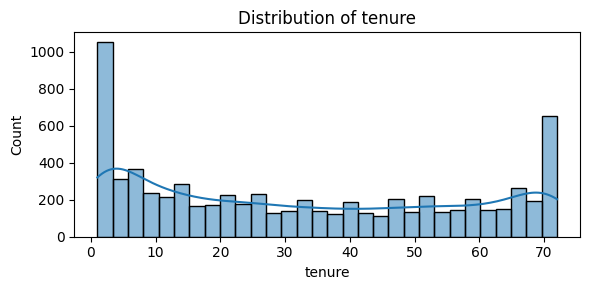

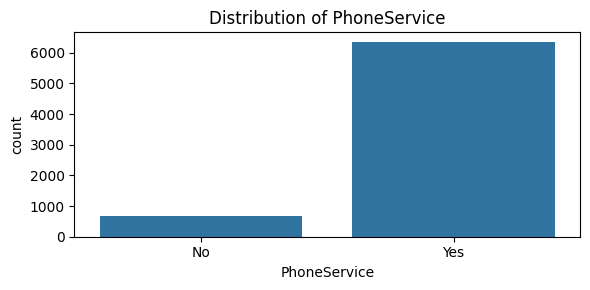

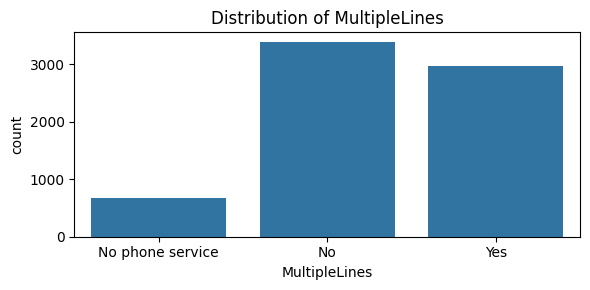

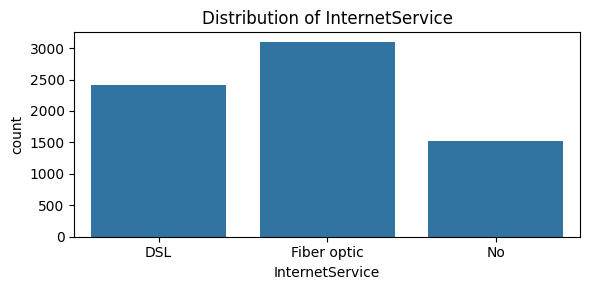

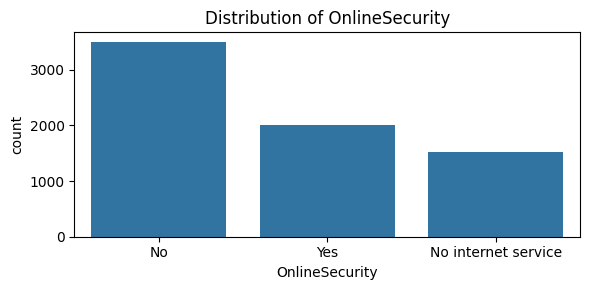

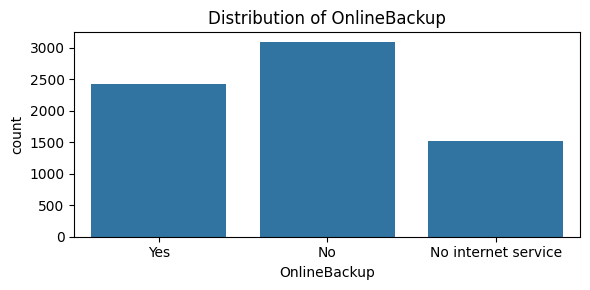

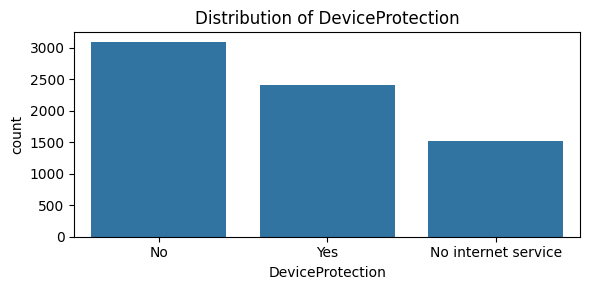

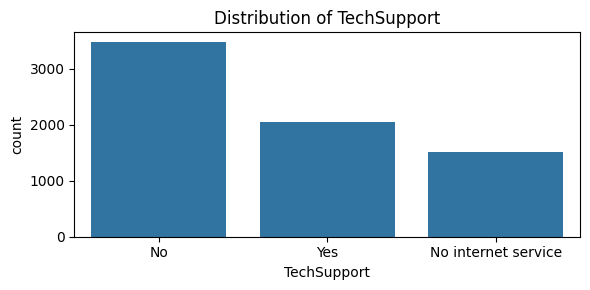

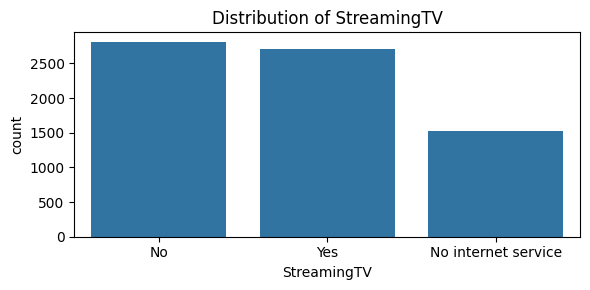

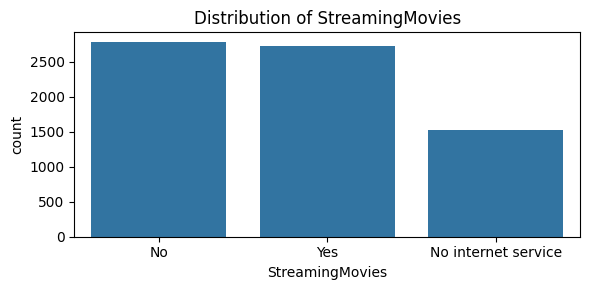

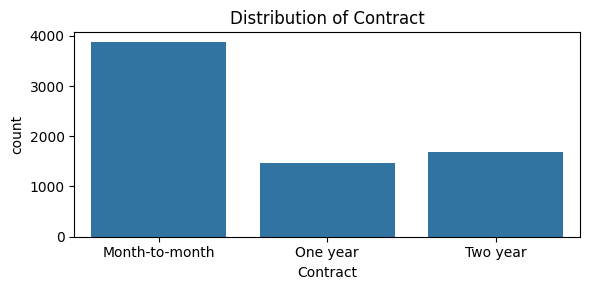

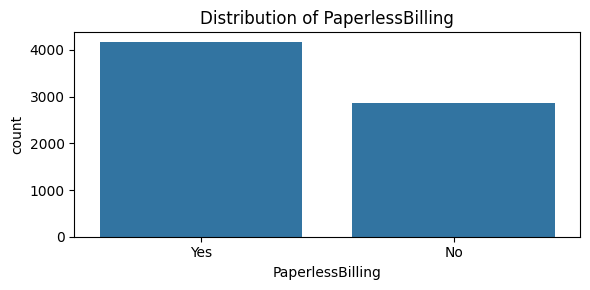

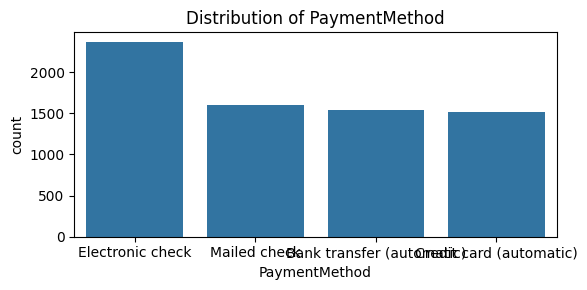

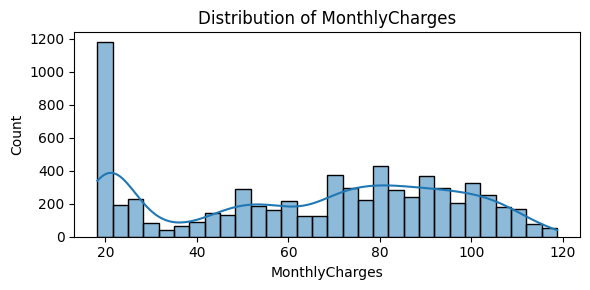

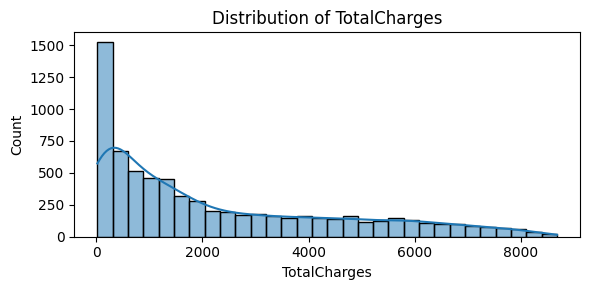

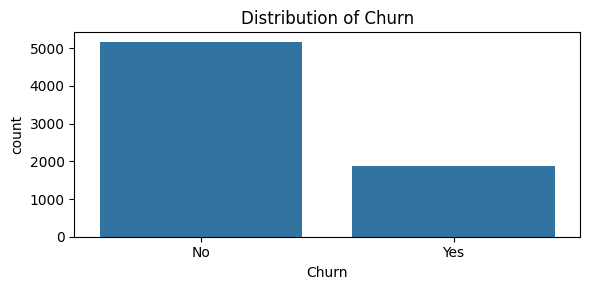

In [88]:
# Column-wise distributions
for col in df.columns:
    plt.figure(figsize=(6, 3))
    if df[col].nunique() < 10:
        sns.countplot(data=df, x=col)
    else:
        sns.histplot(data=df, x=col, bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


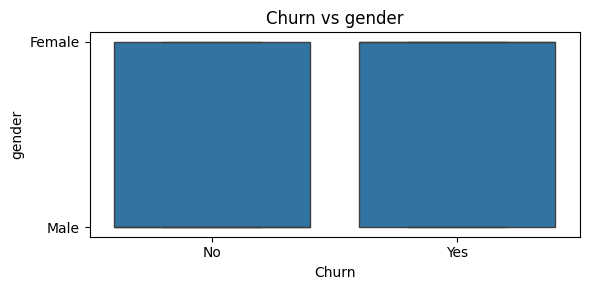

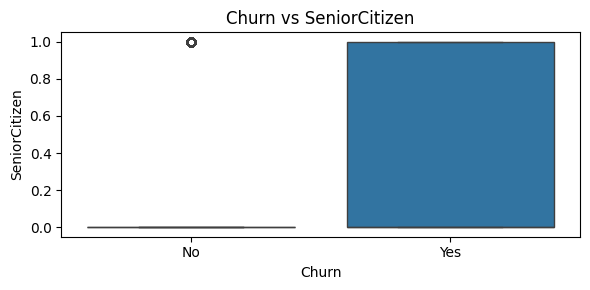

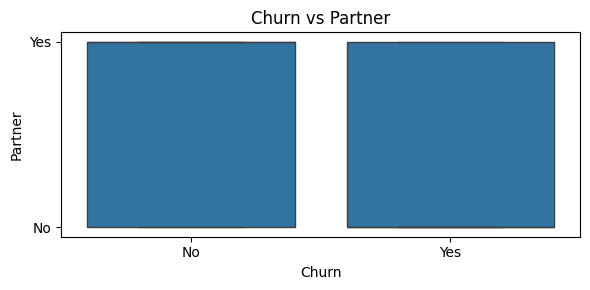

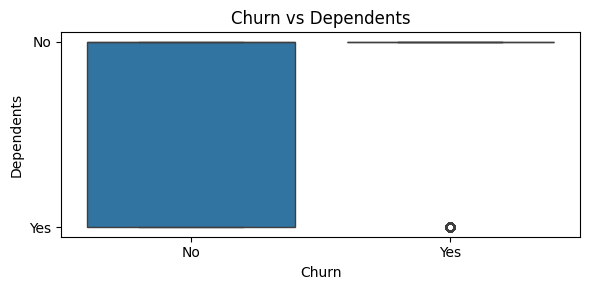

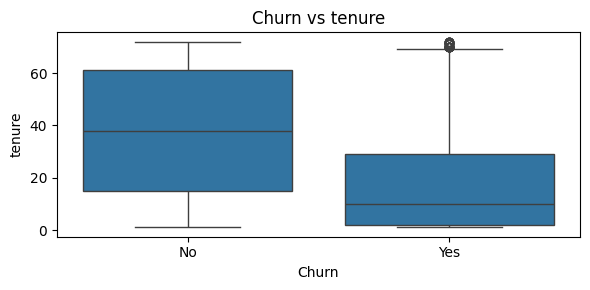

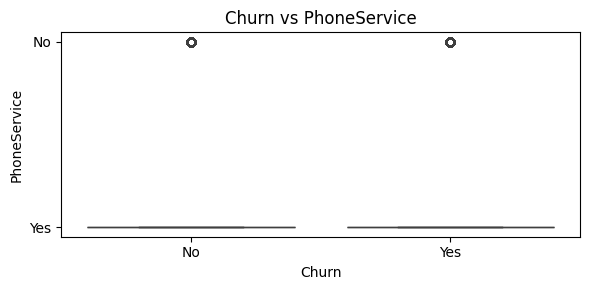

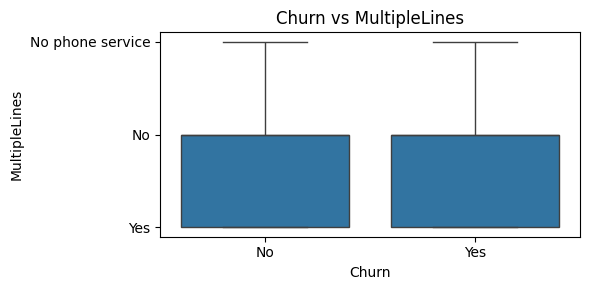

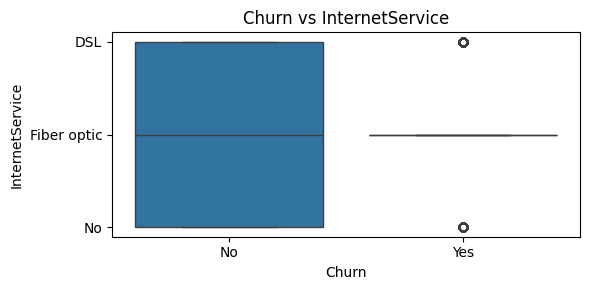

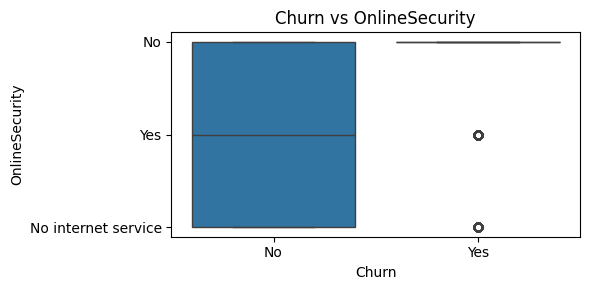

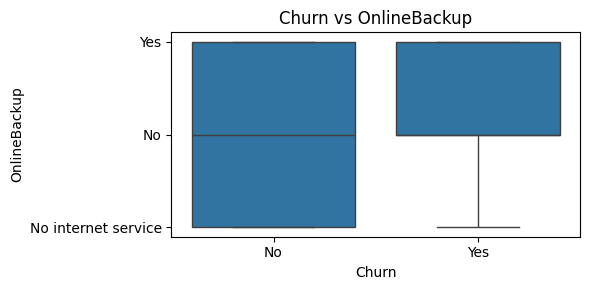

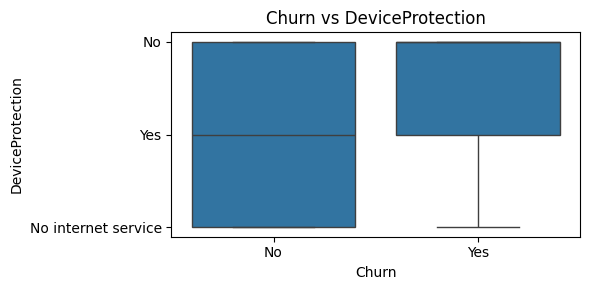

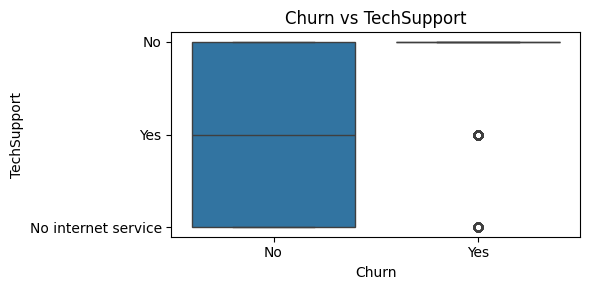

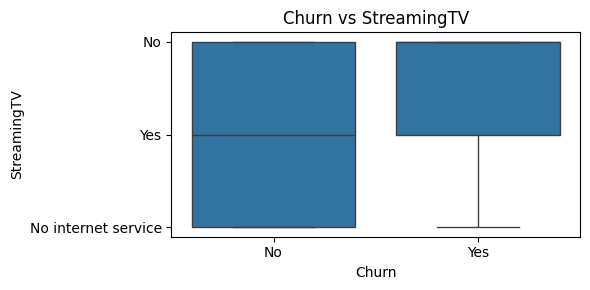

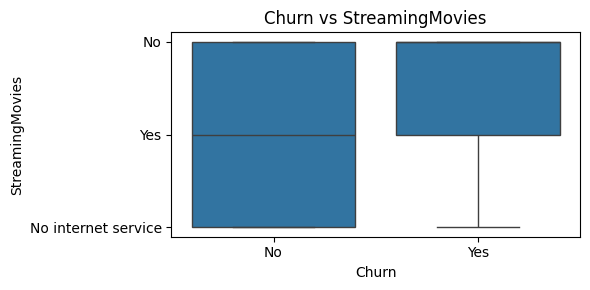

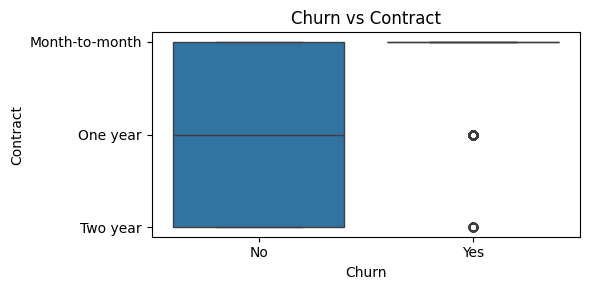

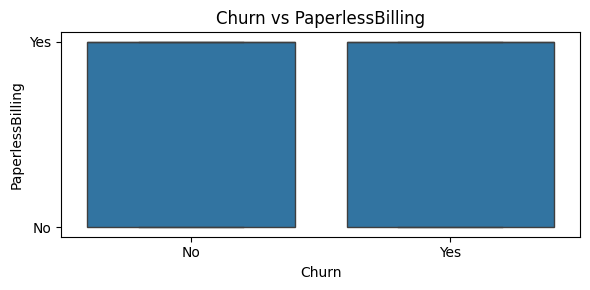

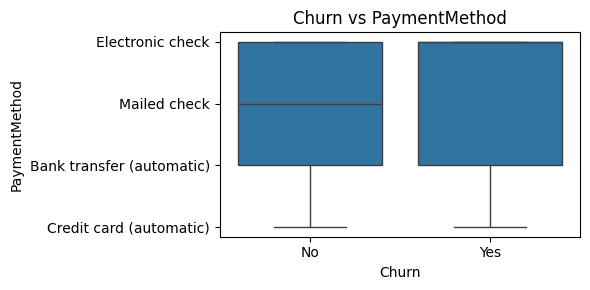

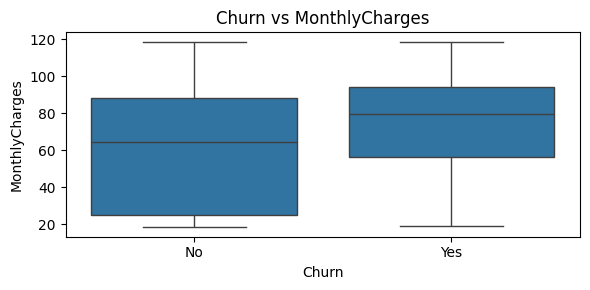

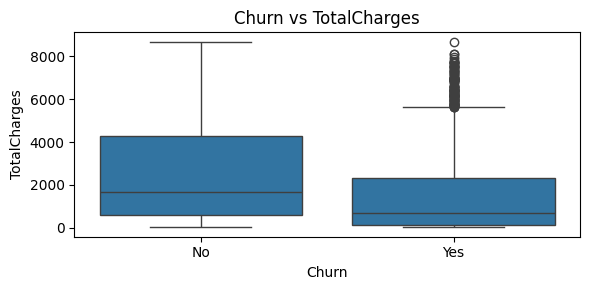

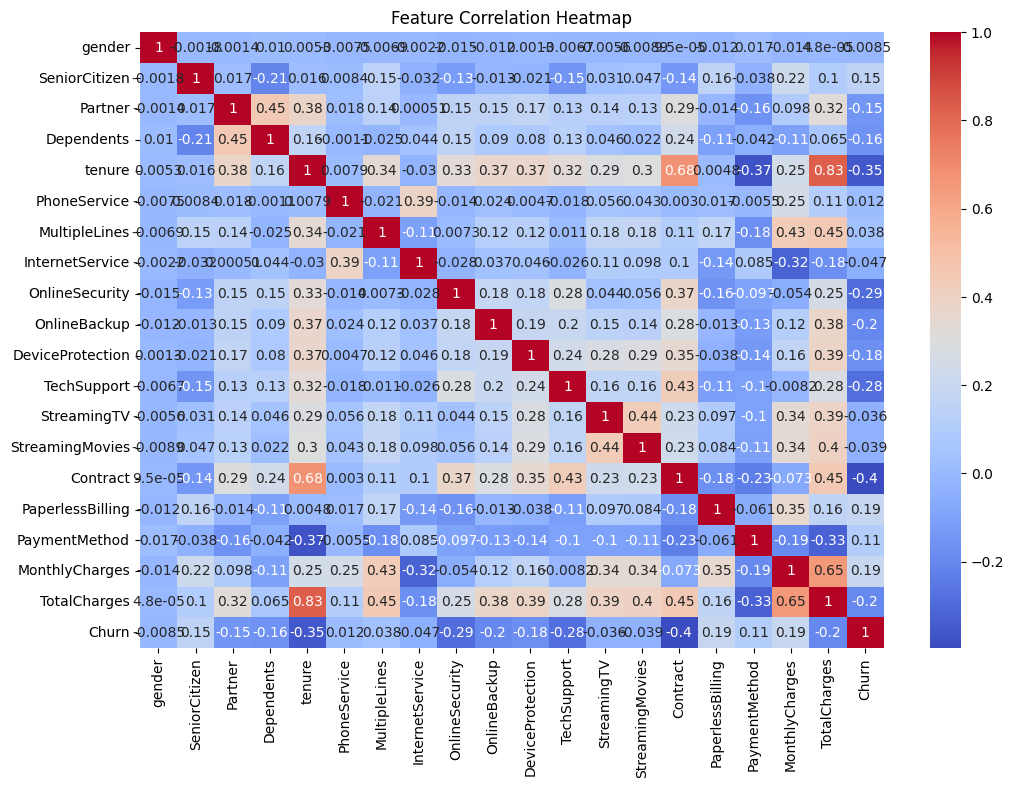

In [89]:
# Bivariate boxplots: Feature vs Churn
for col in df.columns:
    if col != "Churn":
        plt.figure(figsize=(6, 3))
        sns.boxplot(x="Churn", y=col, data=df)
        plt.title(f"Churn vs {col}")
        plt.tight_layout()
        plt.show()

# Correlation heatmap (numeric-only)
corr_matrix = df_encoded.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

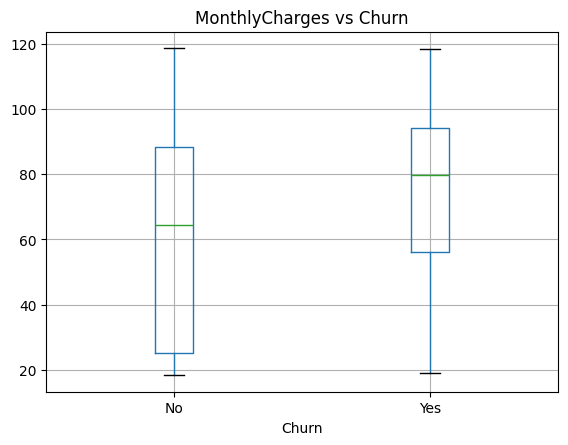

In [90]:
# Hypothesis: Higher MonthlyCharges -> Higher churn
df.boxplot(column="MonthlyCharges", by="Churn")
plt.title("MonthlyCharges vs Churn")
plt.suptitle("")
plt.show()

In [91]:
# Select features based on correlation with target
cor_target = corr_matrix["Churn"].abs()

selected_1 = cor_target[cor_target > 0.1].index.tolist()
selected_2 = cor_target[(cor_target >= 0.5) & (cor_target <= 0.8)].index.tolist()

selected_1.remove("Churn")
selected_2 = [col for col in selected_2 if col != "Churn"]

df_numeric = df_encoded.select_dtypes(include=[np.number])
selected_2 = [col for col in selected_2 if col in df_numeric.columns]

print("Selected columns:", selected_2)
print("X_sel shape:", df_encoded[selected_2].shape)

Selected columns: []
X_sel shape: (7032, 0)


In [92]:
# Prepare features and target
X_full = df_encoded.drop("Churn", axis=1)
y_full = df_encoded["Churn"]

X_sel = df_encoded[selected_2]
y_sel = df_encoded["Churn"]

# Train-test splits
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_sel, y_sel, test_size=0.2, random_state=42)

In [93]:
# Logistic Regression with all features
clf_full = LogisticRegression(max_iter=1000)
clf_full.fit(X_train_full, y_train_full)

print("Full Model Accuracy:", clf_full.score(X_test_full, y_test_full))

Full Model Accuracy: 0.7874911158493249


d:\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [94]:
# Logistic Regression with selected features
clf_sel = LogisticRegression(max_iter=1000)
clf_sel.fit(X_train_sel, y_train_sel)

pred_sel = clf_sel.predict(X_test_sel)
print("Selected Feature Model Accuracy:", accuracy_score(y_test_sel, pred_sel))

ValueError: at least one array or dtype is required